In [1]:
# Repository bootstrap: make local packages importable from any notebook working directory.
from pathlib import Path
import sys
_HERE = Path.cwd().resolve()
_REPO_ROOT = next((p for p in (_HERE, *_HERE.parents) if (p / 'publication_reconstruction').is_dir() and (p / 'data').is_dir()), None)
if _REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root from the notebook working directory.')
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))


# Electrostatic Diagnostics — Synthetic Langmuir and Flow Workflow

This notebook is a reproducible **synthetic demonstration**, not a reconstruction of original IR-T1 measurements. It covers a controlled Langmuir I–V model, floating potential, model-based recovery of electron temperature and plasma potential, an electrostatic-potential gradient, and a compound-probe directional-flow abstraction.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parents[1]))

import numpy as np
from electrostatic_diagnostics.langmuir_probe.synthetic import generate_synthetic_langmuir_iv
from electrostatic_diagnostics.langmuir_probe.analysis import estimate_floating_potential, fit_langmuir_iv
from electrostatic_diagnostics.electric_fields.field import electric_field_from_potential
from electrostatic_diagnostics.compound_probe.synthetic import generate_synthetic_directional_measurements
from electrostatic_diagnostics.compound_probe.flow import estimate_flow_velocity, calculate_mach_numbers
from electrostatic_diagnostics.visualization import plot_langmuir_iv

Known Te = 6.00 eV; recovered = 6.00 eV
Known Vp = 8.00 V; recovered = 7.99 V
Estimated floating potential Vf = 3.85 V


<Axes: title={'center': 'Langmuir I-V characteristic'}, xlabel='Probe voltage (V)', ylabel='Probe current (A)'>

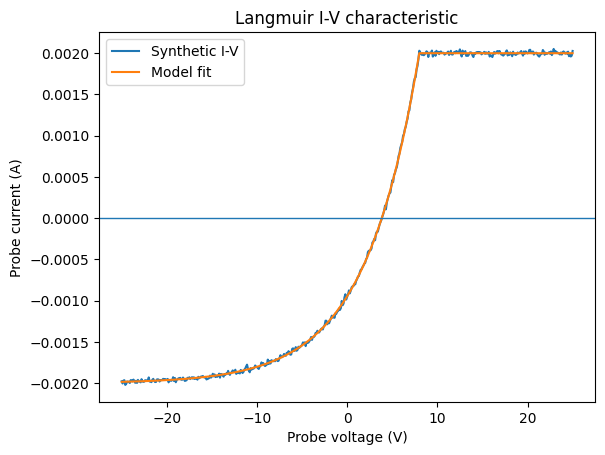

In [3]:
data = generate_synthetic_langmuir_iv()
fit = fit_langmuir_iv(data['voltage'], data['current'])
vf = estimate_floating_potential(data['voltage'], data['current'])
print(f"Known Te = {data['electron_temperature_eV']:.2f} eV; recovered = {fit.electron_temperature_eV:.2f} eV")
print(f"Known Vp = {data['plasma_potential']:.2f} V; recovered = {fit.plasma_potential:.2f} V")
print(f"Estimated floating potential Vf = {vf:.2f} V")
plot_langmuir_iv(data['voltage'], data['current'], fitted_current=fit.fitted_current)

In [4]:
r = np.linspace(0.0, 0.01, 101)
phi = 30.0 - 2500.0*r + 200.0*np.exp(-((r-0.006)/(0.0015))**2)
E_r = electric_field_from_potential(r, phi)
print(f"Central electric field = {E_r[50]:.1f} V/m")

Central electric field = -111131.6 V/m


In [5]:
flow_data = generate_synthetic_directional_measurements()
flow = estimate_flow_velocity(flow_data['directions'], flow_data['measurements_m_s'])
mach = calculate_mach_numbers(flow['velocity_m_s'], electron_temperature_eV=data['electron_temperature_eV'], ion_mass_amu=40.0)
print('Recovered velocity (m/s):', np.round(flow['velocity_m_s'], 1))
print('Parallel Mach number:', round(mach['parallel_mach'], 3))
print('Perpendicular Mach number:', round(mach['perpendicular_mach'], 3))

Recovered velocity (m/s): [17082.1  2447.6  1075. ]
Parallel Mach number: 4.49
Perpendicular Mach number: 0.703
